# Задание 1
Датасет Iris (Kaggle).
Нужно:
- прочитать через pandas
- гистограммы по 4 признакам
- по каждому классу count, mean, var, std, сравнить средние
- 2D карта двух признаков
- 3D карта трех признаков

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Читаем данные

In [50]:
df = pd.read_csv("Iris.csv")
df = df.drop("Id", axis=1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [52]:
print(df.isnull().sum())
print()
print(df["Species"].value_counts())

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [53]:
# список признаков, дальше он много где нужен
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
species = df["Species"].unique()
colors = {"Iris-setosa": "red", "Iris-versicolor": "green", "Iris-virginica": "blue"}
print(species)

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


## Гистограммы признаков

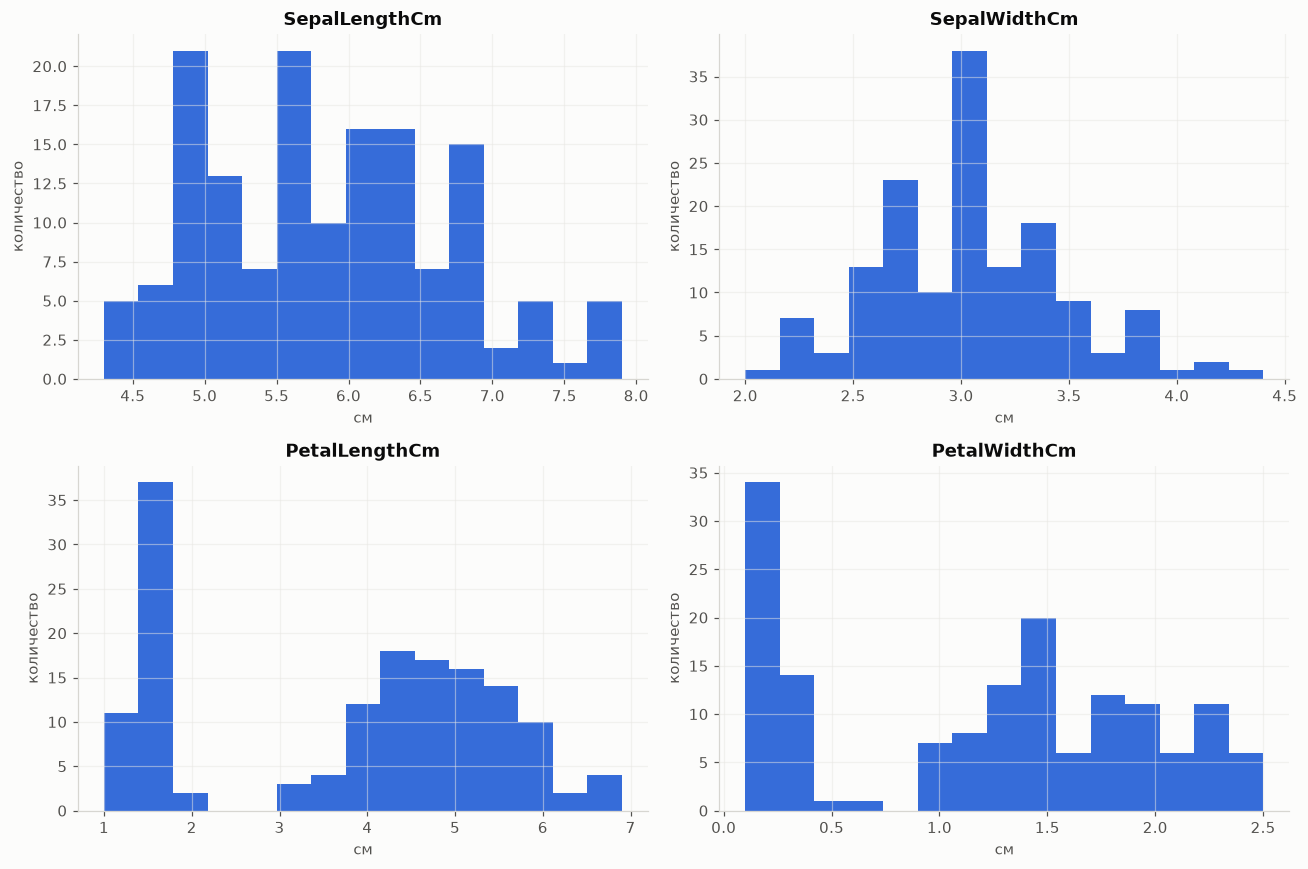

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, f in zip(axes.flatten(), features):
    ax.hist(df[f], bins=15)
    ax.set_title(f)
    ax.set_xlabel("см")
    ax.set_ylabel("количество")

plt.tight_layout()
plt.show()

У длины и ширины лепестка на гистограмме два горба. Посмотрим то же самое, но по сортам.

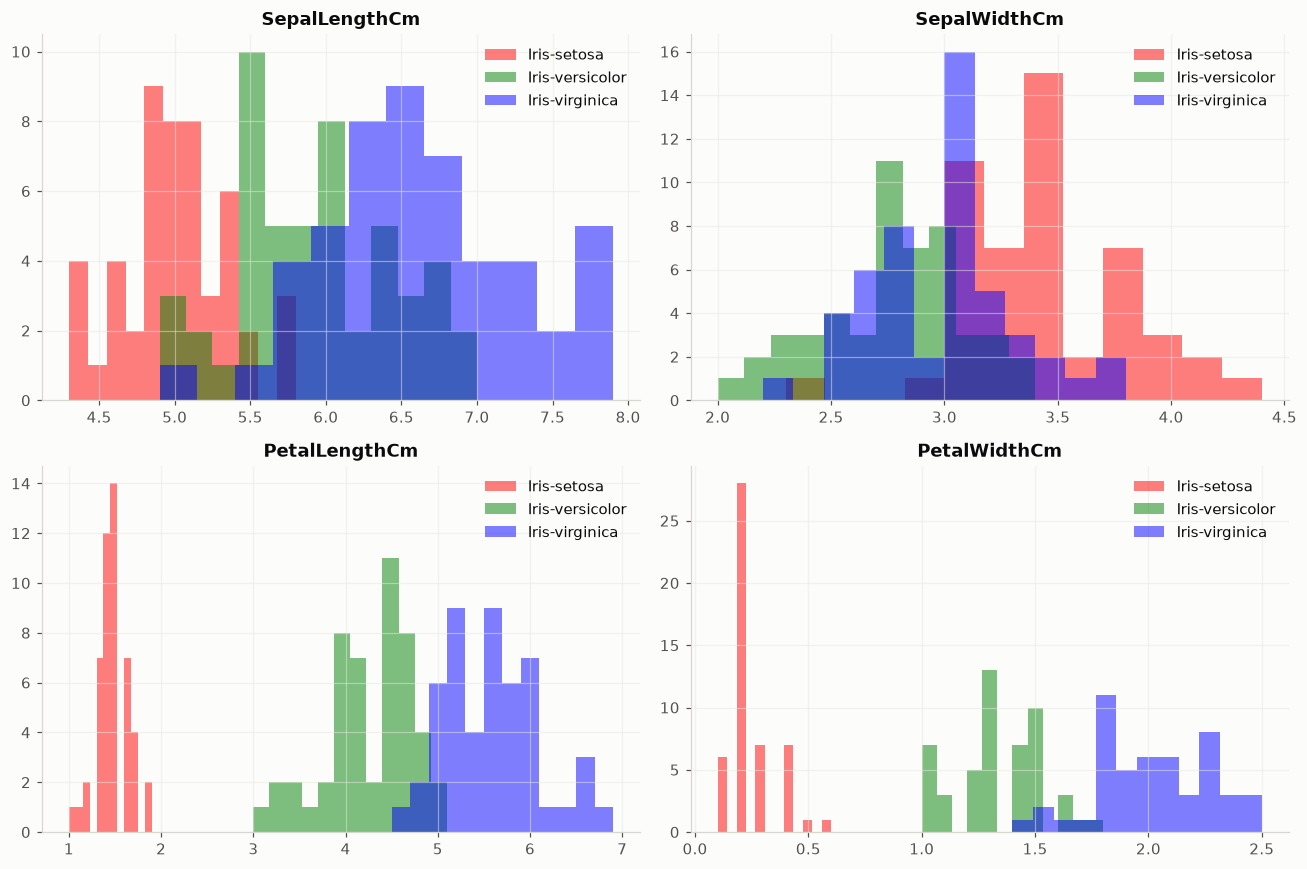

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, f in zip(axes.flatten(), features):
    for s in species:
        ax.hist(df[df["Species"] == s][f], bins=12, alpha=0.5, color=colors[s], label=s)
    ax.set_title(f)
    ax.legend()

plt.tight_layout()
plt.show()

Левый горб - это setosa, у нее лепестки заметно меньше.

## Статистика по классам

In [56]:
stats = df.groupby("Species")[features].agg(["count", "mean", "var", "std"])
stats.round(3)

SepalLengthCm                      SepalWidthCm                \
                        count   mean    var    std        count   mean    var   
Species                                                                         
Iris-setosa                50  5.006  0.124  0.352           50  3.418  0.145   
Iris-versicolor            50  5.936  0.266  0.516           50  2.770  0.098   
Iris-virginica             50  6.588  0.404  0.636           50  2.974  0.104   

                       PetalLengthCm                      PetalWidthCm         \
                   std         count   mean    var    std        count   mean   
Species                                                                         
Iris-setosa      0.381            50  1.464  0.030  0.174           50  0.244   
Iris-versicolor  0.314            50  4.260  0.221  0.470           50  1.326   
Iris-virginica   0.322            50  5.552  0.305  0.552           50  2.026   

                               
                   var    std  
Species                        
Iris-setosa      0.011  0.107  
Iris-versicolor  0.039  0.198  
Iris-virginica   0.075  0.275

In [57]:
# то же самое, но по отдельности - так читать удобнее
for st in ["count", "mean", "var", "std"]:
    print(st)
    print(stats.xs(st, axis=1, level=1).round(3))
    print()

count
                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Species                                                                  
Iris-setosa                 50            50             50            50
Iris-versicolor             50            50             50            50
Iris-virginica              50            50             50            50

mean
                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Species                                                                  
Iris-setosa              5.006         3.418          1.464         0.244
Iris-versicolor          5.936         2.770          4.260         1.326
Iris-virginica           6.588         2.974          5.552         2.026

var
                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Species                                                                  
Iris-setosa              0.124         0.145          0.030         0.011
Iris-versicolor      

### Сравнение средних

In [58]:
means = df.groupby("Species")[features].mean()
means.round(3)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


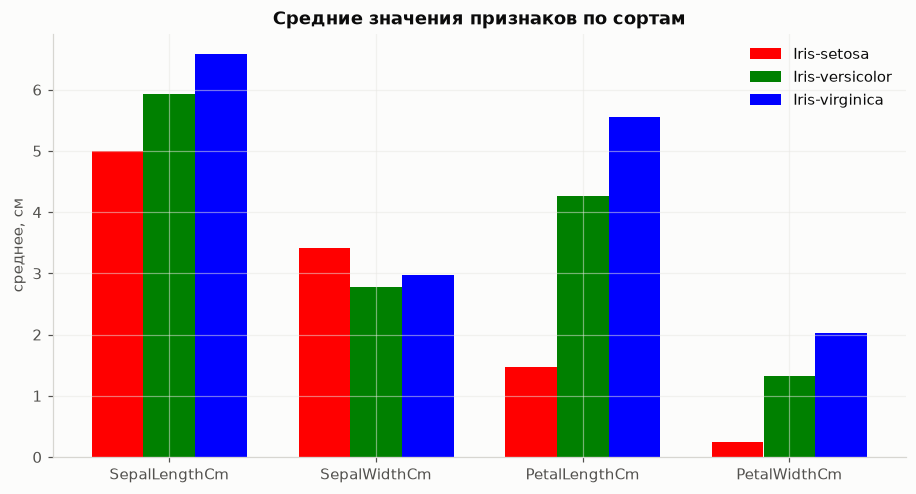

In [59]:
x = np.arange(len(features))
w = 0.25

plt.figure(figsize=(10, 5))
for i, s in enumerate(species):
    plt.bar(x + (i - 1) * w, means.loc[s], width=w, color=colors[s], label=s)

plt.xticks(x, features)
plt.ylabel("среднее, см")
plt.title("Средние значения признаков по сортам")
plt.legend()
plt.show()

In [60]:
# насколько признаки вообще различаются между сортами
print((means.max() - means.min()).round(2))

SepalLengthCm    1.58
SepalWidthCm     0.65
PetalLengthCm    4.09
PetalWidthCm     1.78
dtype: float64


По всем признакам средние растут в порядке setosa -> versicolor -> virginica,кроме ширины чашелистика: там у setosa наоборот самое большое значение.Сильнее всего сорта различаются по длине лепестка (разброс средних около 4 см),слабее всего - по ширине чашелистика. Значит для карт логичнее брать признаки лепестка.

## 2D карта

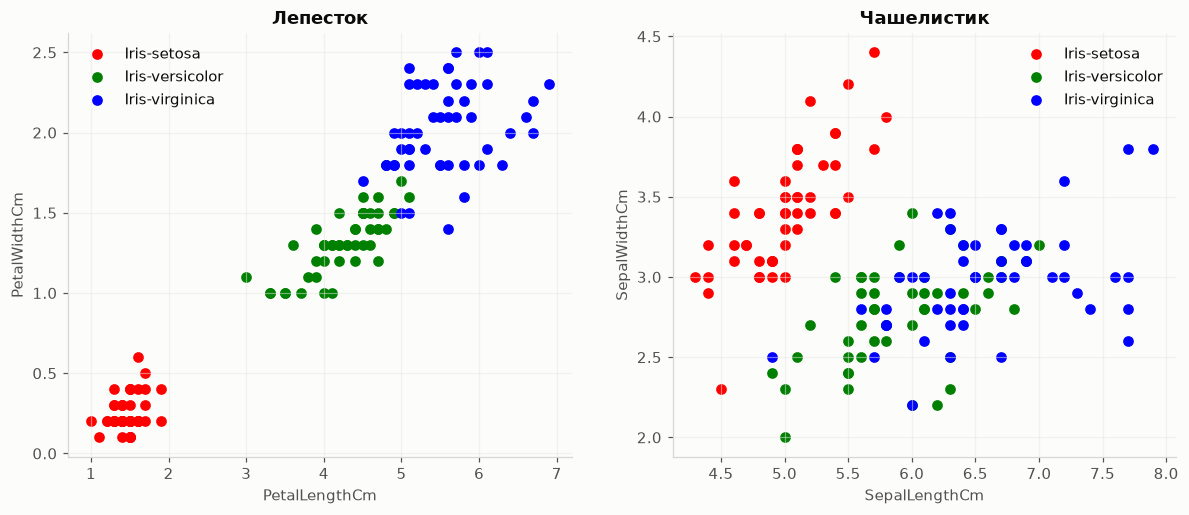

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for s in species:
    sub = df[df["Species"] == s]
    axes[0].scatter(sub["PetalLengthCm"], sub["PetalWidthCm"], color=colors[s], label=s)
    axes[1].scatter(sub["SepalLengthCm"], sub["SepalWidthCm"], color=colors[s], label=s)

axes[0].set_xlabel("PetalLengthCm")
axes[0].set_ylabel("PetalWidthCm")
axes[0].set_title("Лепесток")
axes[0].legend()

axes[1].set_xlabel("SepalLengthCm")
axes[1].set_ylabel("SepalWidthCm")
axes[1].set_title("Чашелистик")
axes[1].legend()

plt.show()

На левом графике setosa отделяется от остальных полностью, versicolor и virginica немного перекрываются. На правом графике по чашелистику versicolor и virginica почти не разделить.

## 3D карта

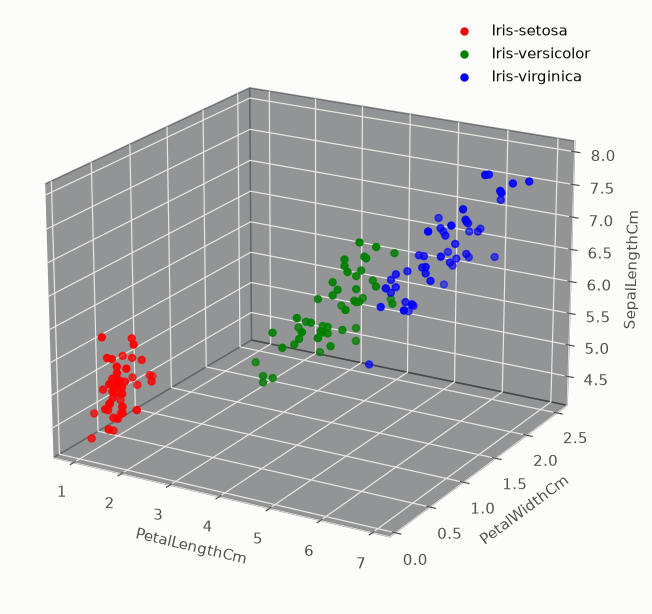

In [62]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

for s in species:
    sub = df[df["Species"] == s]
    ax.scatter(sub["PetalLengthCm"], sub["PetalWidthCm"], sub["SepalLengthCm"],
               color=colors[s], label=s)

ax.set_xlabel("PetalLengthCm")
ax.set_ylabel("PetalWidthCm")
ax.set_zlabel("SepalLengthCm")
ax.view_init(20, -60)
ax.legend()
plt.show()

## Выводы
Пропусков в данных нет, 150 объектов, классы сбалансированы по 50 штук.Setosa хорошо отделяется от двух других сортов уже по двум признакам лепестка,а versicolor и virginica частично перекрываются, поэтому ошибки классификации будут в основном между ними.